In [1]:
import os
import sys; sys.path.append(os.path.join(os.path.abspath(''), '../experiments'));

import experiment_helper
from periodic_simulation_setup import *
import json
import os

import parallelism, multiprocessing, itertools, setproctitle
import os, time, numpy as np

In [2]:

allowBending = False
useTFT = True


name = 'cosine_curve'
time_stamp = time.strftime("%Y_%m_%d_%H_%M")
time_stamp = '2023_12_06_17_08'
base_folder = 'output/{}/{}'.format(name, time_stamp)
if not os.path.exists(base_folder):
    os.makedirs(base_folder)  

# pressure = 0.8
stiffness_pressure = 0.3
scale_factor_pressure = 0.01
disableFusedRegionTFT = False
avg_len = 1

In [3]:
num_experiment = 10

In [4]:
use_half_period = False

In [5]:
h = 5


In [6]:
amplitudes = np.linspace(0, 4.5 * (0.5 if use_half_period else 1) / h, num_experiment)


In [7]:
amplitudes

array([0. , 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9])

In [8]:
label = 5

In [9]:
h = 5

In [10]:
import mesher_helper

In [11]:
importlib.reload(mesher_helper)

<module 'mesher_helper' from '/Users/yren/Develop/Inflatables/python/periodic_patches/Simulation/../../gmsh/mesher_helper.py'>

In [12]:
importlib.reload(pattern_generator_using_gmsh)

<module 'pattern_generator_using_gmsh' from '/Users/yren/Develop/Inflatables/python/periodic_patches/Simulation/../experiments/../pattern_generator_using_gmsh.py'>

In [13]:
amplitude = 0.35

In [14]:
result_folder = "{}/{}".format(base_folder, label)
if not os.path.exists(result_folder):
    os.makedirs(result_folder)  

m, marker = pattern_generator_using_gmsh.get_cosine_curve(h, avg_len, avg_len, amplitude=amplitude, end_threshold = 0.0, use_half_period=use_half_period)

finalMarkers = np.where(np.array(marker) == 1)[0]
m, finalMarkers = periodic_unit_helper.shift_and_merge_2D_periodic_mesh(m, finalMarkers, flip_orientation= 0)
m, finalMarkers = periodic_unit_helper.shift_and_merge_2D_periodic_mesh(m, finalMarkers, axis = 1, flip_orientation= 1)

fusedVtx = get_fusedVtx_using_markers(len(m.vertices()), finalMarkers)

ipu = inflation.InflatablePeriodicUnit(m, fusedVtx = fusedVtx, epsilon = 1e-9)

num_seg: 5
10


In [15]:
base_cosine_curve, curve_edges, boundary_vxs, boundary_lines = pattern_generator_using_gmsh.get_cosine_curve(h, avg_len, avg_len, amplitude=amplitude, end_threshold = 0.0, use_half_period=use_half_period, return_line_segments=True)

num_seg: 5


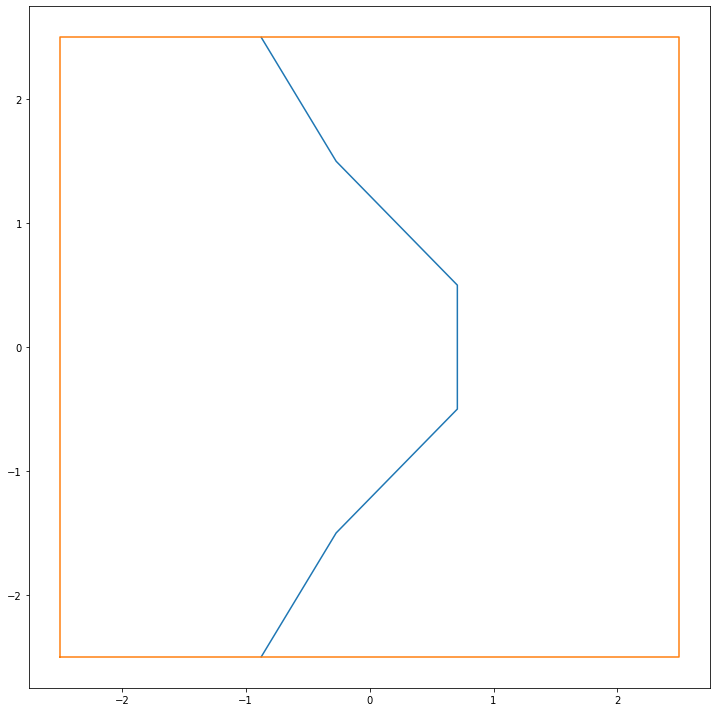

In [16]:
visualization.plot_line_segments(list(base_cosine_curve) + list(boundary_vxs), list(curve_edges - 1) + list(np.array(boundary_lines) - 1 + len(base_cosine_curve)), width = 10, height = 10, path = '{}_cosine_pattern.svg'.format(amplitude))

In [17]:
len(m.boundaryElements()) / 4

11.0

In [18]:
sum(fusedVtx) / 4

9.5

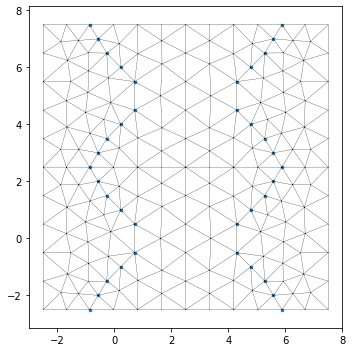

In [19]:
visualization.plot_2d_mesh(m, pointList=np.where(np.array(fusedVtx) == 1)[0], width=5, height=5)


In [20]:
configure_solver_parallelism()


viewer = TriMeshViewer(ipu, width=1024, height=1024)
viewer.showWireframe(True)

In [21]:
viewer.show()

Renderer(camera=PerspectiveCamera(children=(PointLight(color='#999999', position=(0.0, 0.0, 5.0), quaternion=(…

In [22]:
framerate = 1 # Update every 5 iterations
def cb(it):
    if it % framerate == 0:
        viewer.update(scalarField=utils.getStrains(ipu.sheet)[:, 0])

In [23]:
cr = experiment_helper.helper_run_equilibrium(ipu, allow_bending = True, stiffness_pressure = stiffness_pressure)

In [24]:
viewer.update()

In [25]:
import experiment_helper, importlib
importlib.reload(experiment_helper)

<module 'experiment_helper' from '/Users/yren/Develop/Inflatables/python/periodic_patches/Simulation/../experiments/experiment_helper.py'>

In [26]:
curr_vars = ipu.getVars()
curr_vars[-1] = np.pi / 100
ipu.setVars(curr_vars)

In [27]:
H = periodic_unit_helper.getNumpyArrayFromCSC(ipu.hessian())

In [28]:
la.norm(H)

70.34024931670872

In [29]:
la.norm(H[:ipu.numVars() - 2, :ipu.numVars() - 2])

63.62670795280585

In [30]:
la.norm(H[:ipu.numVars() - 2, :ipu.numVars() - 2])

63.62670795280585

In [31]:
stiffness_values, sampled_alphas, stiffness_coefficient = experiment_helper.helper_compute_bending_stiffness(ipu, cb, result_folder = result_folder, name = name, variable = label, render_images = True)

In [32]:
stiffness_values[0]

0.8645271675374734

In [33]:
# import mode_viewer

# import compute_vibrational_modes
# class ModalAnalysisWrapper:
#     def __init__(self, sheet):
#         self.sheet = sheet
#     def hessian(self):
#         return self.sheet.hessian()

# lambdas, modes = compute_vibrational_modes.compute_vibrational_modes(ModalAnalysisWrapper(ipu), mtype=compute_vibrational_modes.MassMatrixType.FULL, n=3, sigma=-1e-10, fixedVars = stiffness_fixedVars)


# import mode_viewer, importlib
# mview = mode_viewer.ModeViewer(ipu, modes, lambdas, amplitude=20, wireframe = False)
# mview.show()

In [34]:
np.set_printoptions(suppress=True, precision=4)

In [35]:
igl.bounding_box(ipu.getVars()[3:-2].reshape(-1, 3))

(array([[ 0.3516,  0.2291,  1.4547],
        [ 0.3516,  0.2291, -1.4547],
        [ 0.3516, -0.2291,  1.4547],
        [ 0.3516, -0.2291, -1.4547],
        [-0.3516,  0.2291,  1.4547],
        [-0.3516,  0.2291, -1.4547],
        [-0.3516, -0.2291,  1.4547],
        [-0.3516, -0.2291, -1.4547]]),
 array([[2, 0, 6],
        [0, 4, 6],
        [5, 4, 0],
        [5, 0, 1],
        [6, 4, 5],
        [5, 7, 6],
        [3, 0, 2],
        [1, 0, 3],
        [3, 2, 6],
        [6, 7, 3],
        [5, 1, 3],
        [3, 7, 5]]))

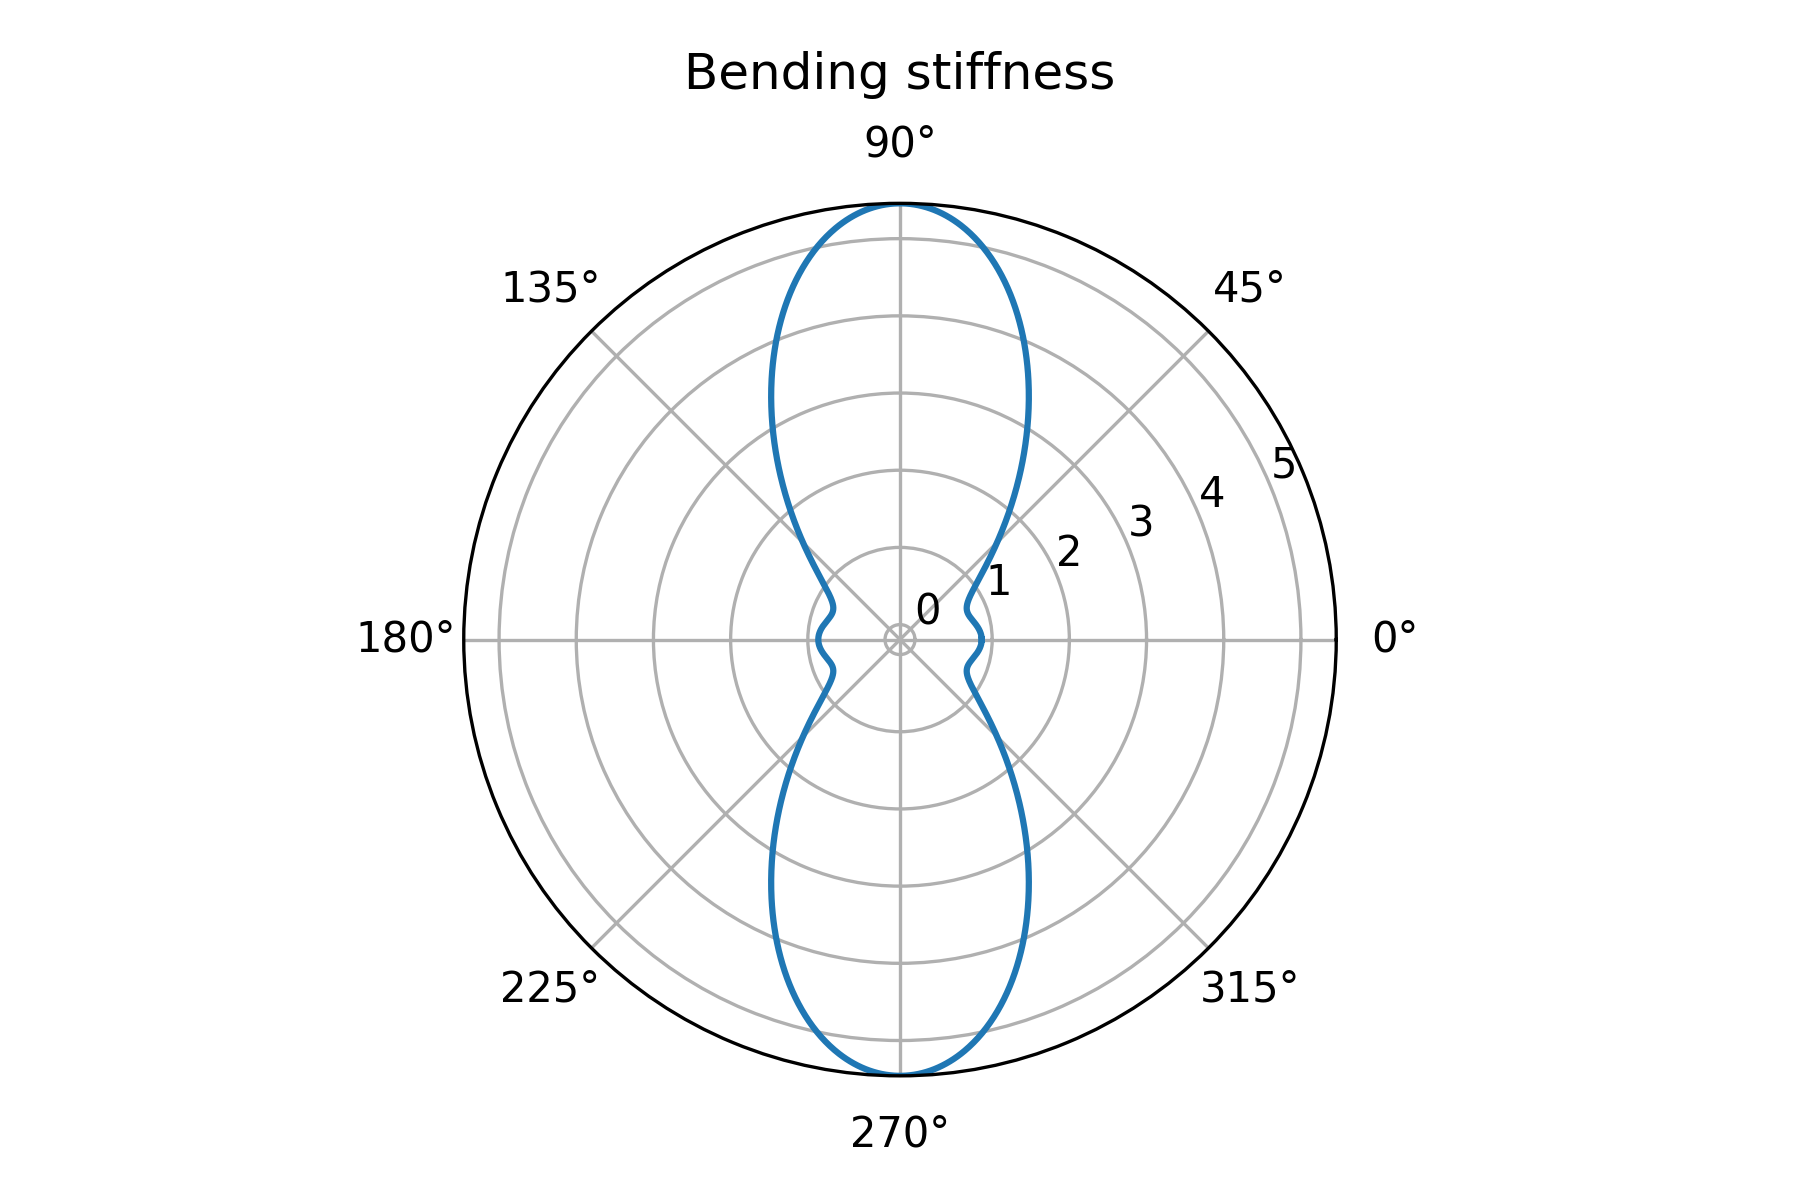

In [36]:
from IPython.display import Image
Image(filename="{}/stiffness_{}_{}.png".format(result_folder, name, label)) 

In [28]:
ipu.getVars()[-2]

In [29]:
np.min(stiffness_values)

In [ ]:
import periodic_simulation_setup
importlib.reload(periodic_simulation_setup)

In [ ]:
periodic_simulation_setup.visualize_average_deformation_gradient(ipu, 1000, show_figure=True, inverse = True, plot_min_r=0)

In [ ]:
periodic_simulation_setup.visualize_average_deformation_gradient(ipu, 1000, show_figure=True, inverse = False, plot_min_r=0)

In [ ]:
la.inv(periodic_simulation_setup.get_deformation_matrix(ipu))

In [48]:
result_folder = "{}/{}".format(base_folder, label)
if not os.path.exists(result_folder):
    os.makedirs(result_folder)  

m, marker = pattern_generator_using_gmsh.get_cosine_curve(h, avg_len, avg_len, amplitude=0.04, end_threshold = 0.0, use_half_period=use_half_period)

finalMarkers = np.where(np.array(marker) == 1)[0]
m, finalMarkers = periodic_unit_helper.shift_and_merge_2D_periodic_mesh(m, finalMarkers, flip_orientation= 0)
m, finalMarkers = periodic_unit_helper.shift_and_merge_2D_periodic_mesh(m, finalMarkers, axis = 1, flip_orientation= 1)

fusedVtx = get_fusedVtx_using_markers(len(m.vertices()), finalMarkers)

fusedVtx[m.boundaryVertices()] = True
isheet = inflation.InflatableSheet(m,  fusedVtx = fusedVtx)


In [60]:
configure_solver_parallelism()


viewer = TriMeshViewer(isheet, width=1024, height=1024)
viewer.showWireframe(True)

In [61]:
viewer.show()

In [52]:
framerate = 1 # Update every 5 iterations
def cb(it):
    if it % framerate == 0:
        viewer.update(scalarField=utils.getStrains(isheet)[:, 0])

In [53]:
importlib.reload(experiment_helper)

In [59]:
isheet = inflation.InflatableSheet(m,  fusedVtx = fusedVtx)

fixedVars, hessianShift = [], 1e-9

isheet.setUseTensionFieldEnergy(useTFT)
isheet.setUseHessianProjectedEnergy(False)
if (disableFusedRegionTFT):
    isheet.disableFusedRegionTensionFieldTheory(False)
isheet.pressure = 0.4

opts.niter = 500
opts.gradTol = 1e-10
cr = inflation.inflation_newton(isheet, fixedVars, opts, callback=cb, hessianShift = hessianShift)
